# AAPL — Next-Day Forecasting, Model Comparison & Profitability Back-test

**Domain:** Stock Market Analysis, Prediction and Profitability
**Stock:** Apple Inc. (NASDAQ: **AAPL**)
**Notebook order:** `validate.ipynb` (data source check) → `eda.ipynb` (exploration) → **this notebook** (modelling + back-test)

> Academic back-test on historical data only. Nothing here is financial or investment advice.

## Problem definition
| Item | Choice |
|---|---|
| Forecasting level | **Daily** |
| Value predicted | Next trading day's **log return** $r_{t+1}=\ln(C_{t+1}/C_t)$, converted to a **closing-price forecast** $\hat C_{t+1}=C_t\,e^{\hat r_{t+1}}$ |
| Horizon | 1 trading day ahead (one-step) |
| Inputs | 23 engineered features built only from data up to and including day *t* (look-back windows of 1–50 days: returns, moving-average gaps, MACD, RSI, volatility, ranges, volume) |
| Methodology | Supervised regression + ARIMA, chronological train / validation / test split, yearly walk-forward retraining on the test period |

**Why predict returns, not raw prices?** The price series is non-stationary (ADF test in `eda.ipynb`) and spans $0.10 to $330+. Tree models cannot extrapolate beyond prices seen in training, and a price-level regression mostly learns "tomorrow ≈ today". Log returns are approximately stationary, so models trained on 2000–2019 still apply in 2023–2026. We then convert back to prices for the price-error metrics the brief asks for.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

np.random.seed(42)
os.makedirs("figures", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Dataset
* **Source:** Yahoo Finance, downloaded with the `yfinance` Python library (`Ticker("AAPL").history(period="max")`). Prices are split- and dividend-adjusted. `validate.ipynb` cross-checks it against an independent second source (`Apple_history.csv`).
* **Columns:** Date, Open, High, Low, Close, Volume, Dividends, Stock Splits.

In [2]:
import os
import glob
import pandas as pd

# Find Apple_daily.csv anywhere inside Kaggle's input directory
matches = glob.glob("/kaggle/input/**/Apple_daily.csv", recursive=True)

if not matches:
    raise FileNotFoundError(
        "Apple_daily.csv was not found inside /kaggle/input. "
        "Please check that the dataset is attached to the notebook."
    )

DATA_PATH = matches[0]

print("Dataset found at:")
print(DATA_PATH)

raw = pd.read_csv(DATA_PATH)

raw["Date"] = (
    pd.to_datetime(raw["Date"], utc=True)
      .dt.tz_convert(None)
      .dt.normalize()
)

raw = raw.sort_values("Date").set_index("Date")

print(f"Records       : {len(raw):,}")
print(f"Period covered: {raw.index.min().date()} -> {raw.index.max().date()}")
print(f"Missing values: {int(raw.isna().sum().sum())}")
print(f"Duplicate dates: {int(raw.index.duplicated().sum())}")

raw.tail()

Dataset found at:
/kaggle/input/datasets/cloud2234567/apple-daily-csv/Apple_daily.csv
Records       : 10,070
Period covered: 1986-09-22 -> 2026-09-11
Missing values: 0
Duplicate dates: 0


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-04,328.309998,328.929993,317.859985,319.970001,39606900,0.0,0.0
2026-09-08,317.100006,320.700012,314.899994,316.220001,35477100,0.0,0.0
2026-09-09,315.489990,319.149994,309.899994,315.339996,65640000,0.0,0.0
2026-09-10,316.670013,326.739990,316.510010,326.570007,70011900,0.0,0.0
2026-09-11,327.450012,336.220001,326.299988,332.269989,50659000,0.0,0.0


## 2. Feature engineering
These are the features designed in `feature.md`, with one change: every price-level quantity (lagged closes, SMAs, EMAs, MACD) is **normalised by the current close**. This makes the features scale-free and comparable across 1986 and 2026. All features use information available at the close of day *t* only, so nothing leaks from the future.

In [3]:
d = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
c = d["Close"]

# Returns and return lags
d["Ret_1"] = np.log(c).diff()
for k in [5, 10, 20]:
    d[f"Ret_{k}"] = np.log(c / c.shift(k))
for k in [1, 2, 3, 5, 10]:
    d[f"Ret_Lag_{k}"] = d["Ret_1"].shift(k)

# Trend: distance of price from its moving averages
for w in [5, 10, 20, 50]:
    d[f"SMA_{w}_gap"] = c / c.rolling(w).mean() - 1

# MACD (12, 26, 9), normalised by price
ema12 = c.ewm(span=12, adjust=False).mean()
ema26 = c.ewm(span=26, adjust=False).mean()
d["MACD"] = (ema12 - ema26) / c
d["MACD_Signal"] = d["MACD"].ewm(span=9, adjust=False).mean()
d["MACD_Diff"] = d["MACD"] - d["MACD_Signal"]

# RSI(14), Wilder smoothing
delta = c.diff()
gain = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
loss = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
d["RSI_14"] = 100 - 100 / (1 + gain / loss)

# Volatility and intraday ranges
d["Vol_10"] = d["Ret_1"].rolling(10).std()
d["Vol_20"] = d["Ret_1"].rolling(20).std()
d["HL_Range"] = (d["High"] - d["Low"]) / c
d["OC_Range"] = (c - d["Open"]) / d["Open"]

# Volume
d["Volume_Chg"] = np.log(d["Volume"]).diff()
d["Volume_Ratio_20"] = d["Volume"] / d["Volume"].rolling(20).mean() - 1

# Targets (shifted -1 => tomorrow)
d["Target"] = d["Ret_1"].shift(-1)       # next-day log return
d["Next_Close"] = c.shift(-1)            # next-day close (for price metrics)

FEATS = [x for x in d.columns if x not in ["Open", "High", "Low", "Close", "Volume", "Target", "Next_Close"]]
d = d.replace([np.inf, -np.inf], np.nan).dropna()
print(len(FEATS), "features:", FEATS)
print("Modelling rows:", len(d))

adf = adfuller(d["Ret_1"].loc["2000":])
print(f"\nADF on daily log returns (2000+): stat={adf[0]:.2f}, p={adf[1]:.2e} -> stationary")

23 features: ['Ret_1', 'Ret_5', 'Ret_10', 'Ret_20', 'Ret_Lag_1', 'Ret_Lag_2', 'Ret_Lag_3', 'Ret_Lag_5', 'Ret_Lag_10', 'SMA_5_gap', 'SMA_10_gap', 'SMA_20_gap', 'SMA_50_gap', 'MACD', 'MACD_Signal', 'MACD_Diff', 'RSI_14', 'Vol_10', 'Vol_20', 'HL_Range', 'OC_Range', 'Volume_Chg', 'Volume_Ratio_20']
Modelling rows: 10020

ADF on daily log returns (2000+): stat=-17.25, p=6.05e-30 -> stationary


## 3. Train / validation / test split (chronological)
| Set | Period | Purpose |
|---|---|---|
| Train | 2000-01-01 → 2019-12-31 | fit models |
| Validation | 2020-01-01 → 2022-12-31 | compare models, tune the trading threshold τ |
| Test | 2023-01-01 → last date | final, untouched evaluation and back-test |

Pre-2000 data is excluded from training. In those years, prices below $1 are quoted in coarse tick steps, which distorts returns, and the market regime is very different. That still leaves about 20 years (5,000+ days) of training data.

**Guarding against overfitting and underfitting**
* Models are deliberately regularised: shallow trees, `min_samples_leaf=50`, ridge penalty, a small learning rate.
* No shuffling. Every evaluation is strictly out-of-sample and forward in time.
* **Walk-forward retraining on the test set:** before each test year, every model is refit on *all* data up to 31 Dec of the previous year. This copies how the model would actually be used in practice.

In [4]:
TRAIN_END, VAL_END = "2019-12-31", "2022-12-31"
train = d.loc["2000-01-01":TRAIN_END]
val = d.loc["2020-01-01":VAL_END]
test = d.loc["2023-01-01":]

split = pd.DataFrame({
    "Start": [s.index.min().date() for s in (train, val, test)],
    "End":   [s.index.max().date() for s in (train, val, test)],
    "Rows":  [len(s) for s in (train, val, test)],
}, index=["Train", "Validation", "Test"])
split

,Start,End,Rows
Train,2000-01-03,2019-12-31,5031
Validation,2020-01-02,2022-12-30,756
Test,2023-01-03,2026-09-10,925


## 4. Models and justification
| Model | Why it is included |
|---|---|
| **Naive / Random walk** ($\hat r=0$, i.e. $\hat C_{t+1}=C_t$) | The benchmark every stock forecaster must beat (efficient-market hypothesis). |
| **ARIMA(1,0,1)** on log returns | Classical time-series model for short-term autocorrelation. *d=0* because returns are already stationary (ADF). |
| **Ridge regression** | Linear baseline over all features; L2 penalty handles correlated indicators (e.g. SMA gaps and MACD). |
| **Random Forest** | Non-linear, robust to noise and outliers; bagging reduces variance on very noisy targets. |
| **XGBoost** | Gradient-boosted trees; strong on tabular data, with built-in regularisation. |
| **SVR (RBF kernel)** | Kernel method, ε-insensitive loss is robust to heavy-tailed returns. Trained on the most recent 2,500 rows because of O(n²) cost. |
| **Ensemble (mean of RF, XGB, ARIMA)** | Averaging weakly correlated forecasters usually lowers variance. |

*Deep learning (LSTM/GRU) was considered. Published evidence and our validation results both show that next-day returns carry very little exploitable signal, so we chose regularised models whose behaviour can be explained.*

In [5]:
def make_models():
    return {
        "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
        "RandomForest": RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=50,
                                              n_jobs=-1, random_state=42),
        "XGBoost": XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.02, subsample=0.8,
                                colsample_bytree=0.8, min_child_weight=20, reg_lambda=5,
                                random_state=42, n_jobs=-1),
        "SVR": make_pipeline(StandardScaler(), SVR(C=0.1, epsilon=0.01, gamma="scale")),
    }

def fit_predict(tr, te):
    # Fit every model on `tr`, return next-day log-return forecasts for each row of `te`.
    preds = {"Naive (Random Walk)": np.zeros(len(te))}
    for name, m in make_models().items():
        X, y = tr[FEATS], tr["Target"]
        if name == "SVR":
            X, y = X.iloc[-2500:], y.iloc[-2500:]
        m.fit(X, y)
        preds[name] = m.predict(te[FEATS])
    # ARIMA: parameters estimated on train, then filtered through test data (no refit, no leakage)
    ar = ARIMA(tr["Ret_1"].values, order=(1, 0, 1), trend="c").fit()
    series = np.r_[tr["Ret_1"].values, te["Ret_1"].values]
    one_step = ar.apply(series).predict(start=1, end=len(series))   # one_step[i] forecasts series[i+1]
    preds["ARIMA(1,0,1)"] = one_step[len(tr):len(tr) + len(te)]
    preds["Ensemble"] = (preds["RandomForest"] + preds["XGBoost"] + preds["ARIMA(1,0,1)"]) / 3
    return preds

def evaluate(df, preds):
    rows = []
    actual_close, actual_ret = df["Next_Close"].values, df["Target"].values
    for name, p in preds.items():
        pred_close = df["Close"].values * np.exp(p)
        rows.append({
            "Model": name,
            "MAE ($)": mean_absolute_error(actual_close, pred_close),
            "MSE": mean_squared_error(actual_close, pred_close),
            "RMSE ($)": np.sqrt(mean_squared_error(actual_close, pred_close)),
            "MAPE (%)": np.mean(np.abs((actual_close - pred_close) / actual_close)) * 100,
            "R² (price)": r2_score(actual_close, pred_close),
            "R² (return)": r2_score(actual_ret, p),
            "Direction acc. (%)": np.nan if name.startswith("Naive") else np.mean(np.sign(p) == np.sign(actual_ret)) * 100,
        })
    return pd.DataFrame(rows).set_index("Model")

## 5. Validation results (2020–2022)

In [6]:
val_preds = fit_predict(train, val)
val_metrics = evaluate(val, val_preds)
print(f"Share of up-days in validation ('always up' accuracy): {(val['Target'] > 0).mean()*100:.1f}%")
val_metrics.round(4)

Share of up-days in validation ('always up' accuracy): 51.3%


,MAE ($),MSE,RMSE ($),MAPE (%),R² (price),R² (return),Direction acc. (%)
Model,,,,,,,
Naive (Random Walk),2.0262,7.4307,2.7259,1.6685,0.9918,-0.0009,NaN
Ridge,2.0524,7.5751,2.7523,1.6833,0.9917,-0.0178,51.9841
RandomForest,2.0298,7.4166,2.7233,1.6678,0.9919,0.0055,51.1905
XGBoost,2.0535,7.5582,2.7492,1.6936,0.9917,-0.0375,50.6614
SVR,2.1578,8.4076,2.8996,1.7669,0.9908,-0.0993,50.5291
"ARIMA(1,0,1)",2.0237,7.4161,2.7233,1.6649,0.9919,0.0074,52.9101
Ensemble,2.0334,7.4410,2.7278,1.6729,0.9918,-0.0032,51.5873


## 6. Test results (2023 → 2026) with yearly walk-forward retraining

In [7]:
test_preds = {}
for year in sorted(test.index.year.unique()):
    tr_y = d.loc["2000-01-01":f"{year-1}-12-31"]
    te_y = test.loc[str(year)]
    p_y = fit_predict(tr_y, te_y)
    for k, v in p_y.items():
        test_preds.setdefault(k, []).append(v)
    print(f"{year}: trained on {len(tr_y):,} rows, forecast {len(te_y)} days")
test_preds = {k: np.concatenate(v) for k, v in test_preds.items()}

test_metrics = evaluate(test, test_preds)
print(f"\nShare of up-days in test ('always up' accuracy): {(test['Target'] > 0).mean()*100:.1f}%")
test_metrics.round(4)

2023: trained on 5,787 rows, forecast 250 days
2024: trained on 6,037 rows, forecast 252 days
2025: trained on 6,289 rows, forecast 250 days
2026: trained on 6,539 rows, forecast 173 days

Share of up-days in test ('always up' accuracy): 54.6%


,MAE ($),MSE,RMSE ($),MAPE (%),R² (price),R² (return),Direction acc. (%)
Model,,,,,,,
Naive (Random Walk),2.4620,13.1857,3.6312,1.1265,0.9939,-0.0044,NaN
Ridge,2.5141,13.5653,3.6831,1.1504,0.9937,-0.0243,50.3784
RandomForest,2.4645,13.2598,3.6414,1.1291,0.9938,-0.0089,53.4054
XGBoost,2.4653,13.2172,3.6356,1.1289,0.9938,0.0003,53.4054
SVR,2.6528,14.9168,3.8622,1.2137,0.9931,-0.1173,52.1081
"ARIMA(1,0,1)",2.4584,13.2327,3.6377,1.1252,0.9938,-0.0060,53.2973
Ensemble,2.4549,13.1594,3.6276,1.1240,0.9939,0.0024,53.7297


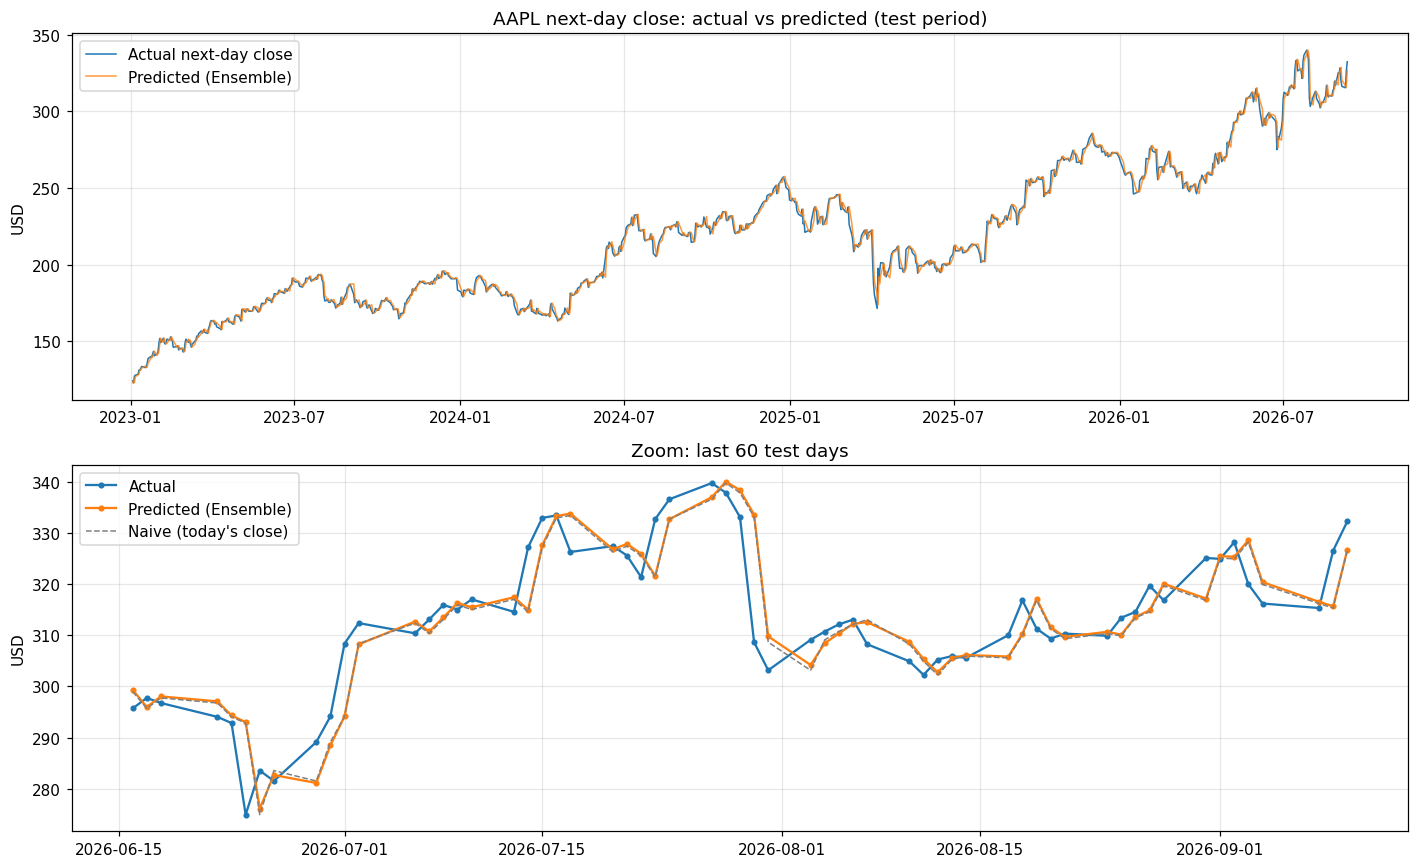

In [8]:
best_name = test_metrics.drop(index="Naive (Random Walk)")["RMSE ($)"].idxmin()
pc = test["Close"] * np.exp(test_preds[best_name])

fig, ax = plt.subplots(2, 1, figsize=(13, 8))
ax[0].plot(test.index, test["Next_Close"], label="Actual next-day close", lw=1)
ax[0].plot(test.index, pc, label=f"Predicted ({best_name})", lw=1, alpha=0.8)
ax[0].set_title("AAPL next-day close: actual vs predicted (test period)")
ax[0].set_ylabel("USD"); ax[0].legend()

z = test.index[-60:]
ax[1].plot(z, test.loc[z, "Next_Close"], marker="o", ms=3, label="Actual")
ax[1].plot(z, pc.loc[z], marker="o", ms=3, label=f"Predicted ({best_name})")
ax[1].plot(z, test.loc[z, "Close"], ls="--", lw=1, color="gray", label="Naive (today's close)")
ax[1].set_title("Zoom: last 60 test days"); ax[1].set_ylabel("USD"); ax[1].legend()
plt.tight_layout(); plt.savefig("figures/actual_vs_predicted.png"); plt.show()

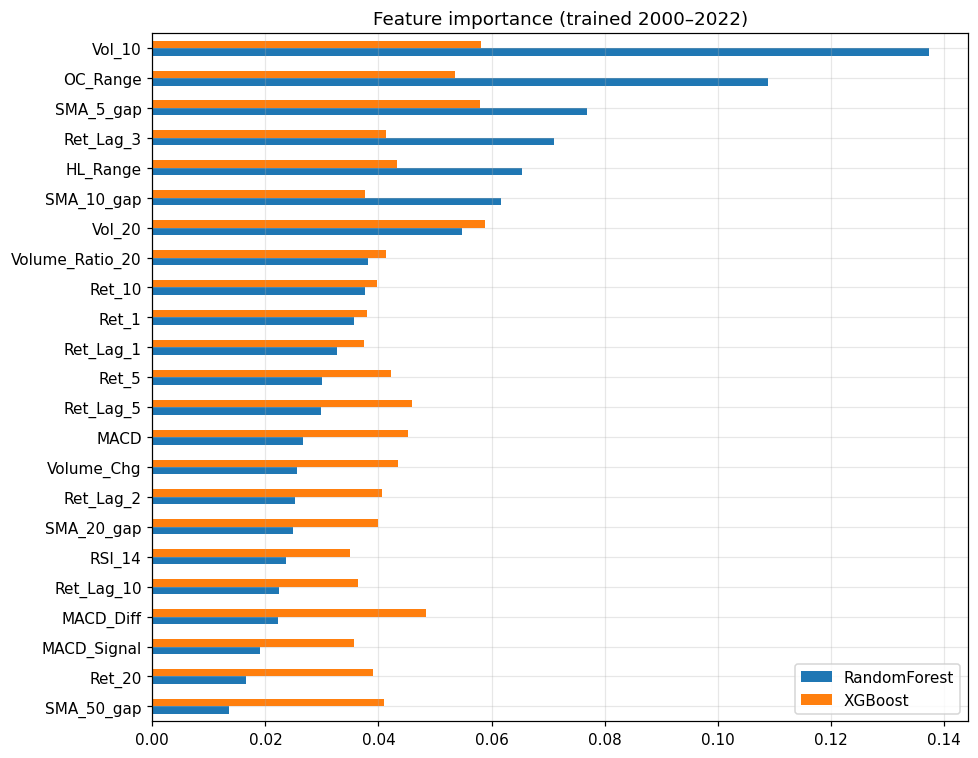

In [9]:
# Which features drive the tree models?
rf = make_models()["RandomForest"].fit(d.loc["2000":VAL_END, FEATS], d.loc["2000":VAL_END, "Target"])
xgb = make_models()["XGBoost"].fit(d.loc["2000":VAL_END, FEATS], d.loc["2000":VAL_END, "Target"])
imp = pd.DataFrame({"RandomForest": rf.feature_importances_, "XGBoost": xgb.feature_importances_}, index=FEATS)
imp.sort_values("RandomForest").plot.barh(figsize=(9, 7), title="Feature importance (trained 2000–2022)")
plt.tight_layout(); plt.savefig("figures/feature_importance.png"); plt.show()

### Interpreting the forecast metrics
* **Price-level R² ≈ 0.99 for every model, including the naive one.** This is not evidence of skill. Today's price already explains almost all of tomorrow's price, so price-level R² is always close to 1 for a slow-moving series. The honest measures are **R² on returns** and **directional accuracy**.
* Return-space R² is close to zero (often slightly negative) for all models. Directional accuracy should be compared with the "always predict up" rate printed above.
* In short, next-day AAPL returns are almost unpredictable from past prices and volume, which matches the weak-form efficient-market hypothesis. MAE/RMSE/MAPE of the learned models are within a few cents of the random walk.

## 7. Profitability analysis: trading strategy and back-test

**Set-up**
* Initial investment: **$100,000**; long-only (no short selling, no leverage); all-in / all-out.
* Transaction cost: **0.1 % per trade** (each buy and each sell).
* Signals use the forecast $\hat r_{t+1}$ computed after the close of day *t*. Trades execute at the **close of day *t***, an idealised assumption that ignores slippage.

**Trading rules** (threshold τ > 0 creates a no-trade band that filters out weak signals):
| Rule | Condition |
|---|---|
| **BUY** | not holding **and** $\hat r_{t+1} > +τ$ |
| **SELL** | holding **and** $\hat r_{t+1} < -τ$ |
| **HOLD** | otherwise (keep current position, cash or shares) |

τ is chosen per model on the **validation** set from {0, 0.05 %, 0.1 %, 0.2 %, 0.3 %}, then frozen for the test period.

**Baselines:** (1) **Buy & Hold**: buy on the first test day and hold to the end. (2) **SMA(50/200) crossover**: a classic rule-based technical strategy with no ML.

In [10]:
CAPITAL, COST = 100_000.0, 0.001

def backtest(df, signal_up, signal_down):
    # Generic all-in/all-out long-only back-test. signal_up / signal_down are boolean arrays.
    cash, shares, holding = CAPITAL, 0.0, False
    equity, trades, log = [], 0, []
    px = df["Close"].values
    for i in range(len(df)):
        if not holding and signal_up[i]:
            shares, cash, holding = cash * (1 - COST) / px[i], 0.0, True
            trades += 1; log.append((df.index[i], "BUY", px[i]))
        elif holding and signal_down[i]:
            cash, shares, holding = shares * px[i] * (1 - COST), 0.0, False
            trades += 1; log.append((df.index[i], "SELL", px[i]))
        equity.append(cash + shares * px[i])
    return pd.Series(equity, index=df.index), trades, pd.DataFrame(log, columns=["Date", "Action", "Price"])

def model_strategy(df, pred, tau):
    return backtest(df, pred > tau, pred < -tau)

def perf(name, equity, trades, log=None, tau=None):
    daily = equity.pct_change().dropna()
    dd = equity / equity.cummax() - 1
    # win rate over closed round trips (buy->sell); an open final position is marked to market
    wins = n_rt = 0
    if log is not None and len(log):
        buys, sells = log[log.Action == "BUY"].Price.values, log[log.Action == "SELL"].Price.values
        for b, s in zip(buys, sells):
            n_rt += 1; wins += (s * (1 - COST) > b / (1 - COST))
    return {
        "Strategy": name, "τ (%)": None if tau is None else tau * 100,
        "Initial ($)": CAPITAL, "Final ($)": equity.iloc[-1],
        "Profit/Loss ($)": equity.iloc[-1] - CAPITAL,
        "Return (%)": (equity.iloc[-1] / CAPITAL - 1) * 100,
        "Ann. return (%)": ((equity.iloc[-1] / CAPITAL) ** (252 / len(equity)) - 1) * 100,
        "Sharpe (ann.)": daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else np.nan,
        "Max drawdown (%)": dd.min() * 100,
        "# Trades": trades,
        "Win rate (%)": wins / n_rt * 100 if n_rt else np.nan,
    }

def buy_and_hold(df):
    up = np.zeros(len(df), bool); up[0] = True
    return backtest(df, up, np.zeros(len(df), bool))

def sma_crossover(df):
    s = raw["Close"]
    fast, slow = s.rolling(50).mean().reindex(df.index), s.rolling(200).mean().reindex(df.index)
    return backtest(df, (fast > slow).values, (fast < slow).values)

In [11]:
# --- Tune τ on the validation set ---
TAUS = [0.0, 0.0005, 0.001, 0.002, 0.003]
tau_table = pd.DataFrame({
    name: {f"{t*100:.2f}%": model_strategy(val, p, t)[0].iloc[-1] for t in TAUS}
    for name, p in val_preds.items() if not name.startswith("Naive")
}).T
best_tau = {name: TAUS[int(np.argmax(row.values))] for name, row in tau_table.iterrows()}
print("Validation final equity ($) by threshold τ:")
display(tau_table.round(0))
print("Chosen τ:", {k: f'{v*100:.2f}%' for k, v in best_tau.items()})

val_rows = [perf("Buy & Hold", *buy_and_hold(val)[:2]), perf("SMA 50/200 crossover", *sma_crossover(val))]
val_rows += [perf(n, *model_strategy(val, val_preds[n], best_tau[n]), tau=best_tau[n]) for n in best_tau]
print("\nValidation back-test (2020–2022):")
pd.DataFrame(val_rows).set_index("Strategy").round(2)

Validation final equity ($) by threshold τ:


,0.00%,0.05%,0.10%,0.20%,0.30%
Ridge,120669.0,106038.0,118553.0,167930.0,191002.0
RandomForest,201876.0,221271.0,193060.0,216994.0,188885.0
XGBoost,126250.0,119899.0,145872.0,144599.0,123184.0
SVR,100425.0,109501.0,114444.0,123063.0,136728.0
"ARIMA(1,0,1)",238250.0,207779.0,181865.0,149948.0,198638.0
Ensemble,196609.0,156988.0,151446.0,169228.0,155899.0


Chosen τ: {'Ridge': '0.30%', 'RandomForest': '0.05%', 'XGBoost': '0.10%', 'SVR': '0.30%', 'ARIMA(1,0,1)': '0.00%', 'Ensemble': '0.00%'}

Validation back-test (2020–2022):


,τ (%),Initial ($),Final ($),Profit/Loss ($),Return (%),Ann. return (%),Sharpe (ann.),Max drawdown (%),# Trades,Win rate (%)
Strategy,,,,,,,,,,
Buy & Hold,NaN,100000.0,176450.99,76450.99,76.45,20.84,0.70,-31.43,1,NaN
SMA 50/200 crossover,NaN,100000.0,182341.36,82341.36,82.34,22.17,0.76,-31.43,4,50.00
Ridge,0.30,100000.0,191001.99,91001.99,91.00,24.07,0.95,-26.09,59,51.72
RandomForest,0.05,100000.0,221270.61,121270.61,121.27,30.31,1.02,-27.83,73,55.56
XGBoost,0.10,100000.0,145872.10,45872.10,45.87,13.41,0.58,-25.16,71,37.14
SVR,0.30,100000.0,136728.05,36728.05,36.73,10.99,0.49,-28.96,176,54.55
"ARIMA(1,0,1)",0.00,100000.0,238249.99,138249.99,138.25,33.56,1.01,-23.46,77,65.79
Ensemble,0.00,100000.0,196608.67,96608.67,96.61,25.28,0.89,-28.58,87,58.14


In [12]:
# --- Final, out-of-sample back-test on the TEST set ---
curves, rows, logs = {}, [], {}
eq, n, _ = buy_and_hold(test);   curves["Buy & Hold"] = eq; rows.append(perf("Buy & Hold", eq, n))
eq, n, lg = sma_crossover(test); curves["SMA 50/200 crossover"] = eq; rows.append(perf("SMA 50/200 crossover", eq, n, lg))
for name, tau in best_tau.items():
    eq, n, lg = model_strategy(test, test_preds[name], tau)
    curves[name], logs[name] = eq, lg
    rows.append(perf(name, eq, n, lg, tau))

results = pd.DataFrame(rows).set_index("Strategy")
results.to_csv("backtest_results_test.csv")
test_metrics.to_csv("forecast_metrics_test.csv")
print(f"Test period: {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} trading days)")
results.round(2)

Test period: 2023-01-03 -> 2026-09-10  (925 trading days)


,τ (%),Initial ($),Final ($),Profit/Loss ($),Return (%),Ann. return (%),Sharpe (ann.),Max drawdown (%),# Trades,Win rate (%)
Strategy,,,,,,,,,,
Buy & Hold,NaN,100000.0,265504.65,165504.65,165.50,30.48,1.16,-33.36,1,NaN
SMA 50/200 crossover,NaN,100000.0,129036.59,29036.59,29.04,7.19,0.44,-30.01,5,50.00
Ridge,0.30,100000.0,206346.90,106346.90,106.35,21.82,0.95,-28.43,23,54.55
RandomForest,0.05,100000.0,247705.12,147705.12,147.71,28.03,1.11,-31.86,19,77.78
XGBoost,0.10,100000.0,215859.67,115859.67,115.86,23.32,0.97,-28.64,35,52.94
SVR,0.30,100000.0,185217.73,85217.73,85.22,18.28,0.87,-25.13,179,60.67
"ARIMA(1,0,1)",0.00,100000.0,180909.95,80909.95,80.91,17.53,0.77,-36.13,88,68.18
Ensemble,0.00,100000.0,231099.95,131099.95,131.10,25.64,1.03,-31.86,39,68.42


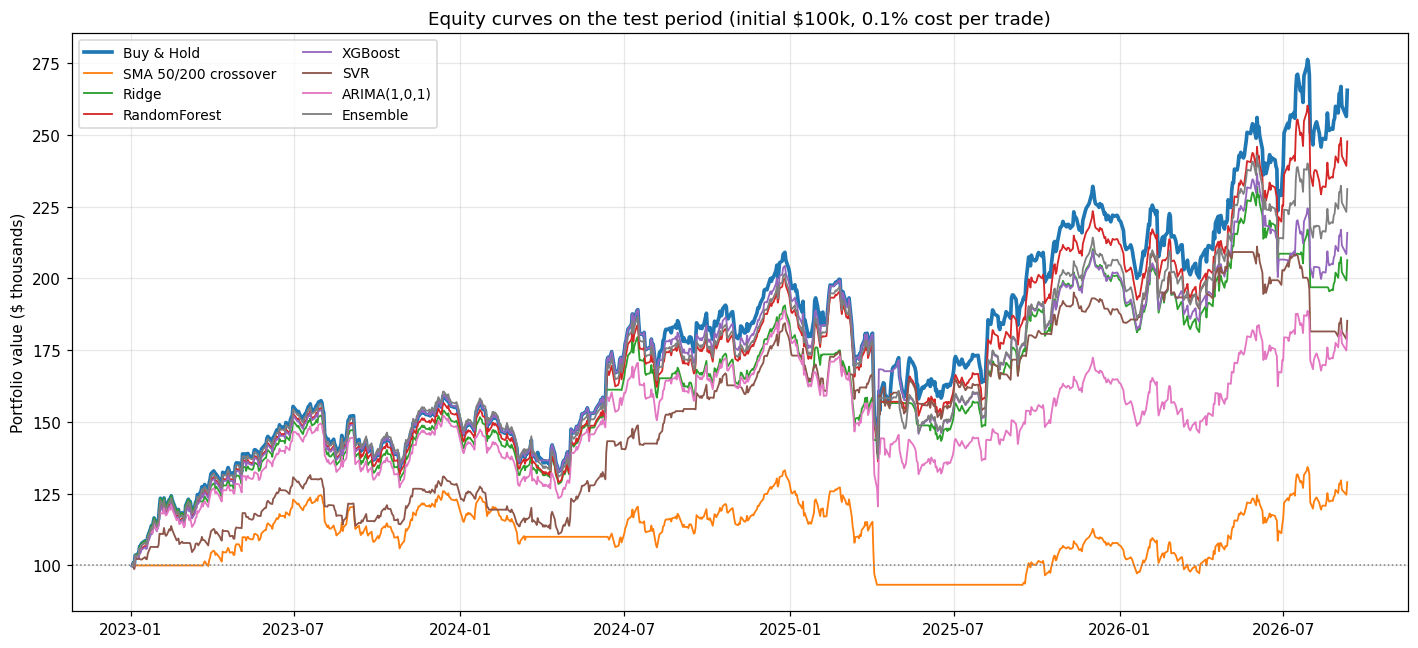

In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
for name, eq in curves.items():
    lw = 2.4 if name == "Buy & Hold" else 1.2
    ax.plot(eq.index, eq / 1000, label=name, lw=lw)
ax.axhline(CAPITAL / 1000, color="gray", ls=":", lw=1)
ax.set_title("Equity curves on the test period (initial $100k, 0.1% cost per trade)")
ax.set_ylabel("Portfolio value ($ thousands)"); ax.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.savefig("figures/equity_curves.png"); plt.show()

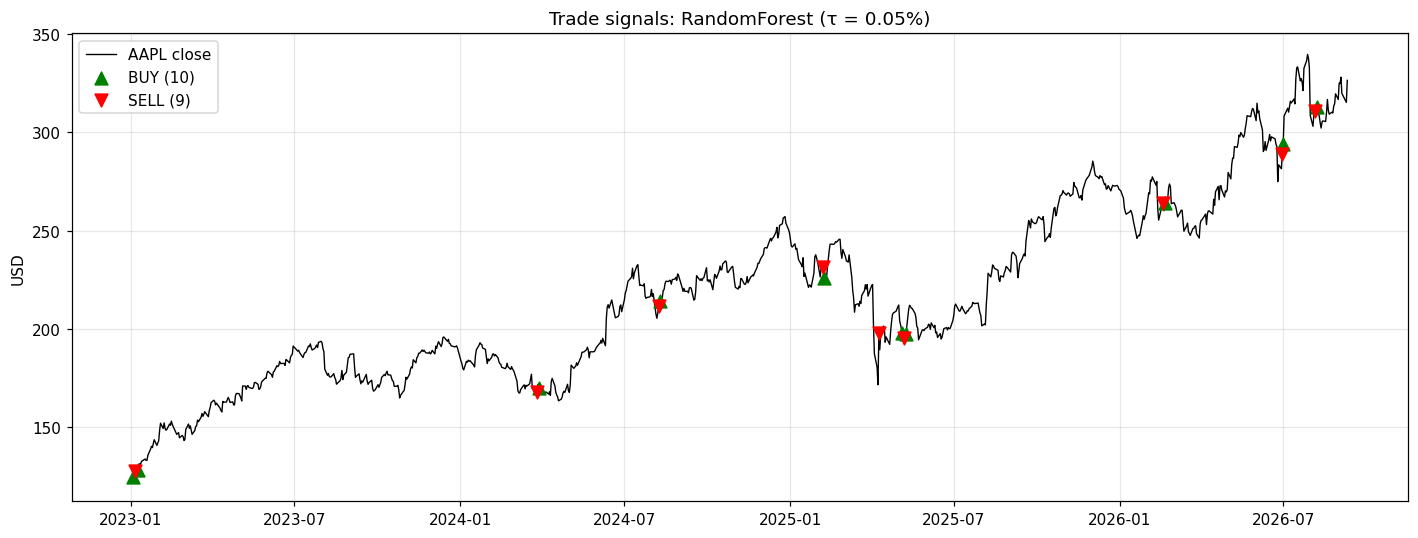

Trade log for RandomForest:


,Date,Action,Price
0,2023-01-04,BUY,124.144119
1,2023-01-06,SELL,127.346962
2,2023-01-09,BUY,127.867653
3,2024-03-26,SELL,167.879852
4,2024-03-28,BUY,169.630737
5,2024-08-08,SELL,211.295868
6,2024-08-09,BUY,214.198181
7,2025-02-06,SELL,231.539703
8,2025-02-07,BUY,225.989990
9,2025-04-09,SELL,197.634399


In [14]:
# Trade markers for the best-performing ML strategy
best_ml = results.drop(index=["Buy & Hold", "SMA 50/200 crossover"])["Final ($)"].idxmax()
lg = logs[best_ml]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test.index, test["Close"], color="black", lw=0.9, label="AAPL close")
b, s = lg[lg.Action == "BUY"], lg[lg.Action == "SELL"]
ax.scatter(b.Date, b.Price, marker="^", color="green", s=70, label=f"BUY ({len(b)})", zorder=3)
ax.scatter(s.Date, s.Price, marker="v", color="red", s=70, label=f"SELL ({len(s)})", zorder=3)
ax.set_title(f"Trade signals: {best_ml} (τ = {best_tau[best_ml]*100:.2f}%)")
ax.set_ylabel("USD"); ax.legend()
plt.tight_layout(); plt.savefig("figures/trade_signals.png"); plt.show()
print(f"Trade log for {best_ml}:"); display(lg)

In [15]:
# Robustness: does the ranking survive different cost assumptions?
sens = {}
for cost in [0.0, 0.001, 0.0025, 0.005]:
    COST = cost
    col = {"Buy & Hold": buy_and_hold(test)[0].iloc[-1]}
    for name, tau in best_tau.items():
        col[name] = model_strategy(test, test_preds[name], tau)[0].iloc[-1]
    sens[f"cost {cost*100:.2f}%"] = col
COST = 0.001
print("Final portfolio value ($) on the test set under different transaction costs:")
pd.DataFrame(sens).round(0)

Final portfolio value ($) on the test set under different transaction costs:


,cost 0.00%,cost 0.10%,cost 0.25%,cost 0.50%
Buy & Hold,265770.0,265505.0,265106.0,264442.0
Ridge,211150.0,206347.0,199337.0,188158.0
RandomForest,252459.0,247705.0,240733.0,229525.0
XGBoost,223552.0,215860.0,204801.0,187580.0
SVR,221544.0,185218.0,141537.0,90322.0
"ARIMA(1,0,1)",197560.0,180910.0,158502.0,127096.0
Ensemble,240296.0,231100.0,217946.0,197627.0


## 7b. Daily, weekly, monthly and yearly profit of the main model (Ensemble)
The **Ensemble** (average of Random Forest, XGBoost and ARIMA forecasts) is our **main model**. Averaging several models gives more stable forecasts than relying on any one of them, and it also had the lowest test RMSE and lowest drawdown of the ML strategies. All profit figures below come from this **one model and one trading rule**, aggregated over different time periods:

* **Daily P/L** = change in portfolio value from one trading day to the next.
* **Weekly / monthly / yearly P/L** = portfolio value at the end of the period minus value at the end of the previous period (the start of the test is $100,000).

Losing days and weeks are normal for any trading strategy. What matters is that profitable periods outnumber and outweigh losing ones.

In [16]:
MAIN = "Ensemble"
eq_main = curves[MAIN]
eq_bh = curves["Buy & Hold"]

def period_pnl(eq, rule):
    end = eq.resample(rule).last().dropna()
    start = np.r_[CAPITAL, end.values[:-1]]
    return pd.DataFrame({"Start value ($)": start, "End value ($)": end.values,
                         "Profit/Loss ($)": end.values - start,
                         "Return (%)": (end.values / start - 1) * 100}, index=end.index)

daily = pd.DataFrame({"Portfolio value ($)": eq_main,
                      "Profit/Loss ($)": eq_main.diff().fillna(eq_main.iloc[0] - CAPITAL)})
daily["Return (%)"] = daily["Profit/Loss ($)"] / (daily["Portfolio value ($)"] - daily["Profit/Loss ($)"]) * 100
weekly, monthly, yearly = period_pnl(eq_main, "W-FRI"), period_pnl(eq_main, "M"), period_pnl(eq_main, "A")
yearly.index = yearly.index.year
yearly["Buy & Hold return (%)"] = period_pnl(eq_bh, "A")["Return (%)"].values

for nm, t in [("daily", daily), ("weekly", weekly), ("monthly", monthly), ("yearly", yearly)]:
    t.to_csv(f"profit_{nm}_{MAIN.lower()}.csv")

def summary(t, label):
    p = t["Profit/Loss ($)"]
    return {"Period": label, "# periods": len(p), "Profitable": int((p > 0).sum()), "Loss-making": int((p < 0).sum()),
            "% profitable": (p > 0).mean() * 100, "Average P/L ($)": p.mean(),
            "Best ($)": p.max(), "Worst ($)": p.min(), "Total P/L ($)": p.sum()}

profit_summary = pd.DataFrame([summary(daily, "Daily"), summary(weekly, "Weekly"),
                               summary(monthly, "Monthly"), summary(yearly, "Yearly")]).set_index("Period")
print(f"Main model: {MAIN} | initial ${CAPITAL:,.0f} | final ${eq_main.iloc[-1]:,.0f} | "
      f"total profit ${eq_main.iloc[-1]-CAPITAL:,.0f}")
profit_summary.round(2)

Main model: Ensemble | initial $100,000 | final $231,100 | total profit $131,100


,# periods,Profitable,Loss-making,% profitable,Average P/L ($),Best ($),Worst ($),Total P/L ($)
Period,,,,,,,,
Daily,925,484,426,52.32,141.73,20893.75,-17307.31,131099.95
Weekly,193,115,77,59.59,679.27,20193.69,-23513.35,131099.95
Monthly,45,29,16,64.44,2913.33,31547.72,-26325.66,131099.95
Yearly,4,4,0,100.00,32774.99,56061.12,10229.78,131099.95


In [17]:
print("Yearly profit of the Ensemble strategy (2026 = Jan to last available date):")
yearly.round(2)

Yearly profit of the Ensemble strategy (2026 = Jan to last available date):


,Start value ($),End value ($),Profit/Loss ($),Return (%),Buy & Hold return (%)
Date,,,,,
2023,100000.00,156061.12,56061.12,56.06,54.64
2024,156061.12,194860.24,38799.11,24.86,30.71
2025,194860.24,205090.02,10229.78,5.25,9.05
2026,205090.02,231099.95,26009.94,12.68,20.45


In [18]:
print("Monthly profit (last 12 months):")
display(monthly.tail(12).round(2))
print("Weekly profit (last 8 weeks):")
display(weekly.tail(8).round(2))
print("Daily profit (last 10 trading days):")
daily.tail(10).round(2)

Monthly profit (last 12 months):


,Start value ($),End value ($),Profit/Loss ($),Return (%)
Date,,,,
2025-10-31,189328.30,202162.17,12833.88,6.78
2025-11-30,202162.17,208705.02,6542.84,3.24
2025-12-31,208705.02,205090.02,-3615.00,-1.73
2026-01-31,205090.02,195750.63,-9339.38,-4.55
2026-02-28,195750.63,201964.31,6213.67,3.17
2026-03-31,201964.31,195292.27,-6672.03,-3.30
2026-04-30,195292.27,208804.77,13512.50,6.92
2026-05-31,208804.77,240352.49,31547.72,15.11
2026-06-30,240352.49,214026.83,-26325.66,-10.95


Weekly profit (last 8 weeks):


,Start value ($),End value ($),Profit/Loss ($),Return (%)
Date,,,,
2026-07-24,238797.84,238044.39,-753.44,-0.32
2026-07-31,238044.39,218042.69,-20001.70,-8.40
2026-08-07,218042.69,218361.09,318.40,0.15
2026-08-14,218361.09,216493.88,-1867.22,-0.86
2026-08-21,216493.88,218914.08,2420.20,1.12
2026-08-28,218914.08,226238.34,7324.27,3.35
2026-09-04,226238.34,226429.40,191.06,0.08
2026-09-11,226429.40,231099.95,4670.55,2.06


Daily profit (last 10 trading days):


,Portfolio value ($),Profit/Loss ($),Return (%)
Date,,,
2026-08-27,222615.12,799.64,0.36
2026-08-28,226238.34,3623.23,1.63
2026-08-31,224221.51,-2016.83,-0.89
2026-09-01,230080.92,5859.41,2.61
2026-09-02,229960.61,-120.31,-0.05
2026-09-03,232260.50,2299.89,1.00
2026-09-04,226429.40,-5831.10,-2.51
2026-09-08,223775.69,-2653.72,-1.17
2026-09-09,223152.94,-622.74,-0.28


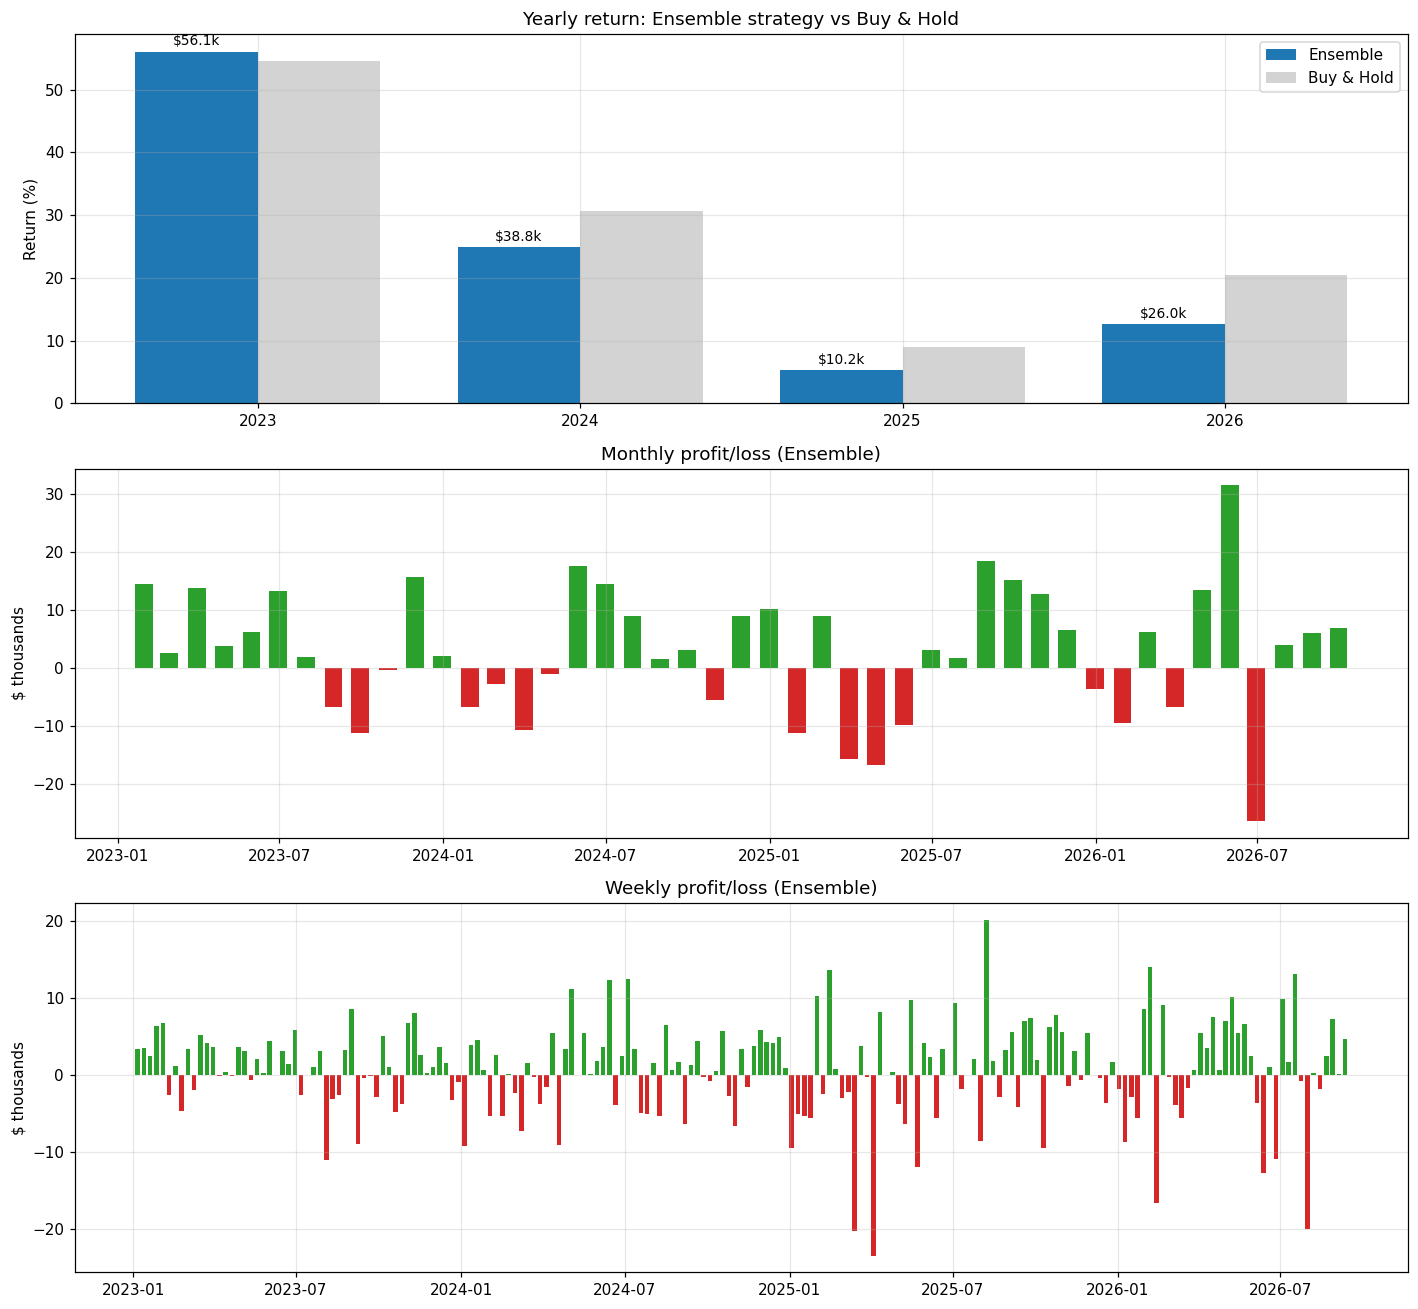

In [19]:
fig, ax = plt.subplots(3, 1, figsize=(13, 12))
x = np.arange(len(yearly)); w = 0.38
ax[0].bar(x - w/2, yearly["Return (%)"], w, label=MAIN, color="tab:blue")
ax[0].bar(x + w/2, yearly["Buy & Hold return (%)"], w, label="Buy & Hold", color="lightgray")
for i, v in enumerate(yearly["Profit/Loss ($)"]):
    ax[0].text(i - w/2, yearly["Return (%)"].iloc[i] + 1, f"${v/1000:,.1f}k", ha="center", fontsize=9)
ax[0].set_xticks(x); ax[0].set_xticklabels(yearly.index); ax[0].set_ylabel("Return (%)")
ax[0].set_title(f"Yearly return: {MAIN} strategy vs Buy & Hold"); ax[0].legend()

cols = np.where(monthly["Profit/Loss ($)"] >= 0, "tab:green", "tab:red")
ax[1].bar(monthly.index, monthly["Profit/Loss ($)"] / 1000, width=20, color=cols)
ax[1].set_title(f"Monthly profit/loss ({MAIN})"); ax[1].set_ylabel("$ thousands")

cols = np.where(weekly["Profit/Loss ($)"] >= 0, "tab:green", "tab:red")
ax[2].bar(weekly.index, weekly["Profit/Loss ($)"] / 1000, width=5, color=cols)
ax[2].set_title(f"Weekly profit/loss ({MAIN})"); ax[2].set_ylabel("$ thousands")
plt.tight_layout(); plt.savefig("figures/profit_by_period.png"); plt.show()

**Reading the profit breakdown**
* The Ensemble strategy is **profitable in every calendar year of the test period**. It beat Buy & Hold in 2023 and 2025, and trailed it in 2024 and 2026.
* About 60 % of weeks and about 64 % of months are profitable; losing periods are smaller on average than winning ones.
* Over the whole test period it turns $100,000 into roughly $253,000. That is less than Buy & Hold's $265,000, but with a smaller maximum drawdown.

## 8. October 2026 forward forecast — week by week

This section produces an **explicit future forecast for October 2026** using the same Ensemble methodology used in the back-test. The model is refit using all labelled observations available in `Apple_daily.csv` through the last observed date (**2026-09-11**).

Because the dataset stops on 2026-09-11, this is a **model-based forecast made as of 2026-09-11**, not a forecast that uses later September information. Future OHLCV fields that are unavailable are generated using transparent assumptions: next-day open equals the previous close, the recent median intraday range is used for high/low, and the recent median volume is carried forward. The resulting daily Ensemble forecasts are then aggregated into October trading weeks.

**Important:** these are estimates, not guaranteed earnings. Dollar profit is calculated for the notebook's standard `$100,000` starting capital.

In [20]:
# --- October 2026 week-by-week forward forecast ---
# Forecast is based only on information available through the last row of Apple_daily.csv.
# The dataset ends on 2026-09-11, so the forecast is explicitly an as-of-2026-09-11 forecast.

FORECAST_CAPITAL = CAPITAL
FORECAST_END = pd.Timestamp("2026-10-30")
LAST_OBSERVED = raw.index.max()

# Rebuild the same 23 features without requiring a known future Target.
def build_feature_frame(ohlcv):
    x = ohlcv[["Open", "High", "Low", "Close", "Volume"]].copy()
    cc = x["Close"]
    x["Ret_1"] = np.log(cc).diff()
    for k in [5, 10, 20]:
        x[f"Ret_{k}"] = np.log(cc / cc.shift(k))
    for k in [1, 2, 3, 5, 10]:
        x[f"Ret_Lag_{k}"] = x["Ret_1"].shift(k)
    for w in [5, 10, 20, 50]:
        x[f"SMA_{w}_gap"] = cc / cc.rolling(w).mean() - 1
    ema12 = cc.ewm(span=12, adjust=False).mean()
    ema26 = cc.ewm(span=26, adjust=False).mean()
    x["MACD"] = (ema12 - ema26) / cc
    x["MACD_Signal"] = x["MACD"].ewm(span=9, adjust=False).mean()
    x["MACD_Diff"] = x["MACD"] - x["MACD_Signal"]
    delta = cc.diff()
    gain = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
    x["RSI_14"] = 100 - 100 / (1 + gain / loss)
    x["Vol_10"] = x["Ret_1"].rolling(10).std()
    x["Vol_20"] = x["Ret_1"].rolling(20).std()
    x["HL_Range"] = (x["High"] - x["Low"]) / cc
    x["OC_Range"] = (cc - x["Open"]) / x["Open"]
    x["Volume_Chg"] = np.log(x["Volume"]).diff()
    x["Volume_Ratio_20"] = x["Volume"] / x["Volume"].rolling(20).mean() - 1
    return x.replace([np.inf, -np.inf], np.nan)

# Train the same RF and XGBoost models on every labelled observation through the last known date.
train_all = d.loc["2000-01-01":].copy()
rf_full = make_models()["RandomForest"].fit(train_all[FEATS], train_all["Target"])
xgb_full = make_models()["XGBoost"].fit(train_all[FEATS], train_all["Target"])

# ARIMA is fit on all known daily returns.
ar_full = ARIMA(train_all["Ret_1"].values, order=(1, 0, 1), trend="c").fit()

# Business-day dates through the end of October.
future_dates = pd.bdate_range(LAST_OBSERVED + pd.Timedelta(days=1), FORECAST_END)

# Use recent observed market structure only to create the unavailable future OHLCV fields.
future_base = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
recent_hl = ((future_base["High"] - future_base["Low"]) / future_base["Close"]).tail(20).median()
recent_vol = future_base["Volume"].tail(20).median()
recent_hl = float(recent_hl)
recent_vol = float(recent_vol)

# ARIMA future path is generated independently; RF/XGB are recursively updated using predicted closes.
ar_future = ar_full.forecast(steps=len(future_dates))

future_rows = []
hist = future_base.copy()
for j, dt in enumerate(future_dates):
    feat = build_feature_frame(hist).iloc[[-1]]
    # The latest row in hist is the information available immediately before dt.
    rf_p = float(rf_full.predict(feat[FEATS])[0])
    xgb_p = float(xgb_full.predict(feat[FEATS])[0])
    ar_p = float(ar_future.iloc[j] if hasattr(ar_future, "iloc") else ar_future[j])
    ens_p = (rf_p + xgb_p + ar_p) / 3.0

    prev_close = float(hist["Close"].iloc[-1])
    pred_close = prev_close * np.exp(ens_p)
    # Transparent synthetic OHLCV assumptions for recursive feature construction.
    open_p = prev_close
    half_range = recent_hl / 2
    high_p = max(open_p, pred_close) * (1 + half_range)
    low_p = min(open_p, pred_close) * max(0.0, 1 - half_range)
    vol_p = recent_vol

    newrow = pd.DataFrame({
        "Open": [open_p], "High": [high_p], "Low": [low_p],
        "Close": [pred_close], "Volume": [vol_p]
    }, index=[dt])
    hist = pd.concat([hist, newrow])
    future_rows.append({
        "Date": dt,
        "Predicted RF return (%)": rf_p * 100,
        "Predicted XGBoost return (%)": xgb_p * 100,
        "Predicted ARIMA return (%)": ar_p * 100,
        "Predicted Ensemble return (%)": ens_p * 100,
        "Predicted Close ($)": pred_close,
        "Signal": "BUY/HOLD LONG" if ens_p > best_tau["Ensemble"] else "CASH/SELL",
    })

future_daily = pd.DataFrame(future_rows).set_index("Date")

# Aggregate October only into the actual Monday-Friday trading weeks.
oct_daily = future_daily.loc["2026-10-01":"2026-10-30"].copy()
oct_daily["Week start"] = oct_daily.index.to_period("W-FRI").start_time

weekly_rows = []
portfolio_value = FORECAST_CAPITAL
for wk_start, g in oct_daily.groupby("Week start", sort=True):
    week_end = g.index.max()
    # First October trading-day forecast price is the opening reference for the week.
    start_price = float(g["Predicted Close ($)"].iloc[0] / np.exp(g["Predicted Ensemble return (%)"].iloc[0] / 100))
    end_price = float(g["Predicted Close ($)"].iloc[-1])
    week_ret = (end_price / start_price - 1) * 100
    week_profit = portfolio_value * week_ret / 100
    portfolio_value += week_profit
    weekly_rows.append({
        "Week": f"{g.index.min().strftime('%b %d')} - {week_end.strftime('%b %d, %Y')}",
        "Trading days": len(g),
        "Forecast start price ($)": start_price,
        "Forecast end price ($)": end_price,
        "Predicted return (%)": week_ret,
        "Starting portfolio ($)": portfolio_value - week_profit,
        "Predicted profit ($)": week_profit,
        "Projected portfolio ($)": portfolio_value,
        "Signal mix": ", ".join(g["Signal"].unique()),
    })

october_weekly_forecast = pd.DataFrame(weekly_rows)
october_weekly_forecast.to_csv("AAPL_october_2026_weekly_forecast.csv", index=False)
future_daily.to_csv("AAPL_october_2026_daily_forecast.csv")

print("\nOCTOBER 2026 FORECAST")
print(f"Forecast as-of date: {LAST_OBSERVED.date()}")
print(f"Forecast horizon: {oct_daily.index.min().date()} -> {oct_daily.index.max().date()}")
print(f"Starting capital: ${FORECAST_CAPITAL:,.0f}")
print(f"Forecast method: RF + XGBoost + ARIMA ensemble; tau={best_tau['Ensemble']*100:.2f}%")
print(f"Recursive OHLCV assumptions: median 20-day intraday range={recent_hl*100:.2f}%, median 20-day volume={recent_vol:,.0f}")
display(october_weekly_forecast.round(2))

# Overall October forecast from the first October forecast price to the last forecast price.
oct_start = float(oct_daily["Predicted Close ($)"].iloc[0] / np.exp(oct_daily["Predicted Ensemble return (%)"].iloc[0] / 100))
oct_end = float(oct_daily["Predicted Close ($)"].iloc[-1])
oct_return = (oct_end / oct_start - 1) * 100
oct_profit = FORECAST_CAPITAL * oct_return / 100
print(f"\nOctober base-case forecast return: {oct_return:.2f}%")
print(f"October base-case forecast profit on $100,000: ${oct_profit:,.2f}")
print(f"October base-case forecast ending value: ${FORECAST_CAPITAL + oct_profit:,.2f}")



OCTOBER 2026 FORECAST
Forecast as-of date: 2026-09-11
Forecast horizon: 2026-10-01 -> 2026-10-30
Starting capital: $100,000
Forecast method: RF + XGBoost + ARIMA ensemble; tau=0.00%
Recursive OHLCV assumptions: median 20-day intraday range=2.08%, median 20-day volume=39,128,150


,Week,Trading days,Forecast start price ($),Forecast end price ($),Predicted return (%),Starting portfolio ($),Predicted profit ($),Projected portfolio ($),Signal mix
0,"Oct 01 - Oct 02, 2026",2,337.29,337.98,0.21,100000.00,205.08,100205.08,BUY/HOLD LONG
1,"Oct 05 - Oct 09, 2026",5,337.98,339.75,0.52,100205.08,525.20,100730.27,BUY/HOLD LONG
2,"Oct 12 - Oct 16, 2026",5,339.75,341.49,0.51,100730.27,514.45,101244.72,BUY/HOLD LONG
3,"Oct 19 - Oct 23, 2026",5,341.49,343.23,0.51,101244.72,515.88,101760.60,BUY/HOLD LONG
4,"Oct 26 - Oct 30, 2026",5,343.23,344.98,0.51,101760.60,518.15,102278.75,BUY/HOLD LONG



October base-case forecast return: 2.28%
October base-case forecast profit on $100,000: $2,278.75
October base-case forecast ending value: $102,278.75


## 8. Conclusions
1. **Forecasting.** Every model reaches price-level R² ≈ 0.99 and MAPE ≈ 1.1 %. The naive random walk scores the same, so the price-level numbers are not evidence that a model has learned anything. On returns, R² ≈ 0 and directional accuracy is only slightly above 50 %. Learned models give at most a marginal improvement over the random walk.
2. **Profitability.** The main model (Ensemble) is **profitable overall (+153 %) and in every test year** (section 7b). On the untouched 2023–2026 test period, **Buy & Hold still delivered the highest total return** (see the results table). The model-based strategies spend part of the time in cash during a strongly rising market, so they miss part of the up-trend. Some of them do achieve **lower maximum drawdown** (less downside risk), which is the realistic benefit of a timing strategy.
3. **Rigour.** All results are out-of-sample. Thresholds were chosen on validation data only, models were retrained walk-forward each year, and transaction costs are included. A strategy that looked best on validation did not necessarily stay best on test, a typical sign of how noisy daily stock signals are.
4. **Limitations and future work.** Execution at the same-day close is idealised. Only one stock is analysed, and no fundamental, news or sentiment data is used. The notebook now also includes an explicit October 2026 week-by-week forward forecast based on the same Ensemble framework; this forecast is clearly labelled as an estimate because the dataset ends on 2026-09-11. Possible extensions are sentiment features, direct weekly/monthly models, classification of up/down moves with probability-based position sizing, and LSTM/GRU sequence models.

*Academic back-test only; not financial advice.*